# Categorical features

`effector` distinguishes three feature types (see `docs/method_semantics.md` for the exact formulas):

| type | meaning | example |
|---|---|---|
| `continuous` | any real value is valid | temperature |
| `ordinal` | discrete levels with a natural order | counts, ratings |
| `nominal` | discrete levels without an order | color, weekday |

Types arrive through the `schema=` argument, or are inferred: pandas dtypes decide on DataFrames (`category` → nominal, ordered `category` → ordinal, low-cardinality int → ordinal), and integer-valued low-cardinality columns of a numpy array are read as ordinal (with a warning — declare types to silence it).

The capability matrix:

| method | continuous | ordinal | nominal |
|---|---|---|---|
| PDP / ICE | ✓ | ✓ levels, bars | ✓ levels, bars |
| DerPDP | ✓ | error | error |
| ALE | ✓ | ✓ exact | ✓ + order caveat |
| RHALE | ✓ | ✓ + level grouping | error |
| ShapDP | ✓ | ✓ per level | ✓ per level |

In [1]:
import numpy as np
import pandas as pd
import effector
from effector import models

np.random.seed(21)

## A model with a categorical feature of interest

We use the closed-form model $f(x) = a_{x_0} + b_{x_0}\, x_1 \, \mathbb{1}_{x_2>0}$ with $x_0 \in \{0, 1, 2\}$, $a = [0, 1, 3]$, $b = [1, -1, 0]$: the effect of $x_0$ is a per-level constant, and its *heterogeneity* comes from the interaction with $x_1, x_2$.

In [2]:
model = models.ConditionalCategorical()

N = 1_000
rng = np.random.default_rng(21)
data = np.stack([
    rng.choice([0.0, 1.0, 2.0], N, p=[0.5, 0.3, 0.2]),
    rng.uniform(-1, 1, N),
    rng.uniform(-1, 1, N),
], axis=1)

schema = {"feature_names": ["level", "x1", "x2"], "feature_types": ["ordinal", "continuous", "continuous"]}

## PDP: bars at the levels, ICE as jittered dots

For a discrete feature the model is evaluated **only at the observed levels** — never at fake in-between values.

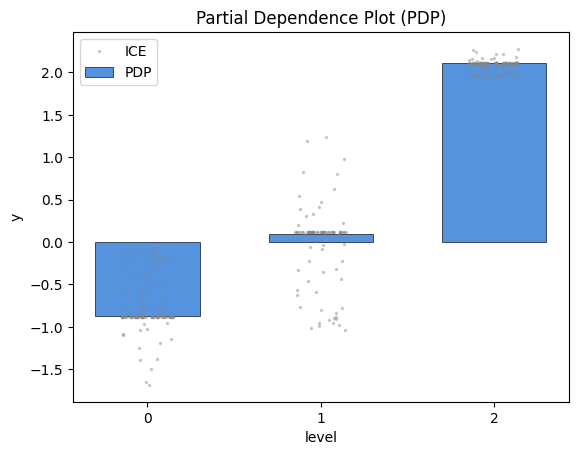

In [3]:
pdp = effector.PDP(data, model.predict, schema=schema)
pdp.plot(0, heterogeneity="ice", centering=True)

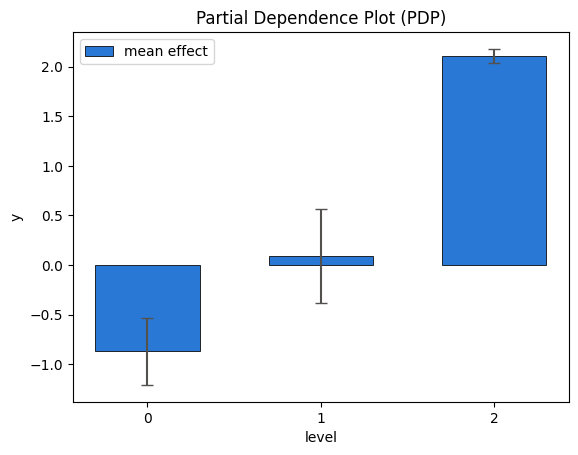

In [4]:
pdp.plot(0, heterogeneity="std", centering=True)

`eval` follows the same rule — asking for a non-level value is an error:

In [5]:
print(pdp.eval(0, np.array([0.0, 1.0, 2.0]), centering="zero_start"))
try:
    pdp.eval(0, np.array([0.5]))
except ValueError as e:
    print("ValueError:", e)

[0.         0.96102959 2.9805148 ]
ValueError: level is categorical and can only be evaluated at its observed levels [0.0, 1.0, 2.0]; got invalid value(s) [0.5]


## ALE: adjacent-level differences, accumulated

Each bar is the accumulated effect at a level; the whisker is the standard deviation of the *step into* that level. For an ordinal feature this is exact — the model is only queried at real levels.

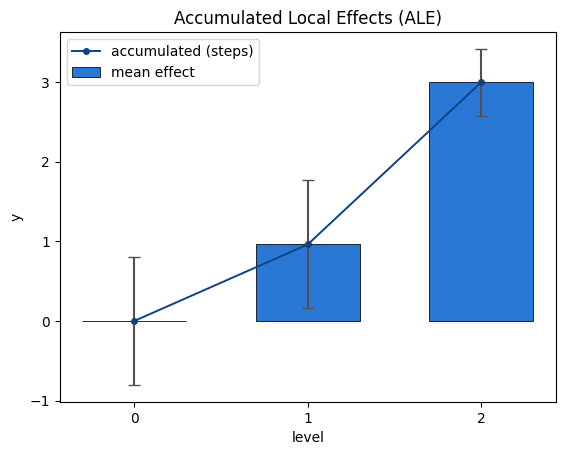

In [6]:
ale = effector.ALE(data, model.predict, schema=schema)
ale.plot(0, centering="zero_start")

## RHALE: adaptive level grouping

On ordinal features RHALE treats the adjacent-level differences as a discrete derivative and lets Greedy/DP binning merge neighboring transitions with similar effect — useful for high-cardinality ordinal features.

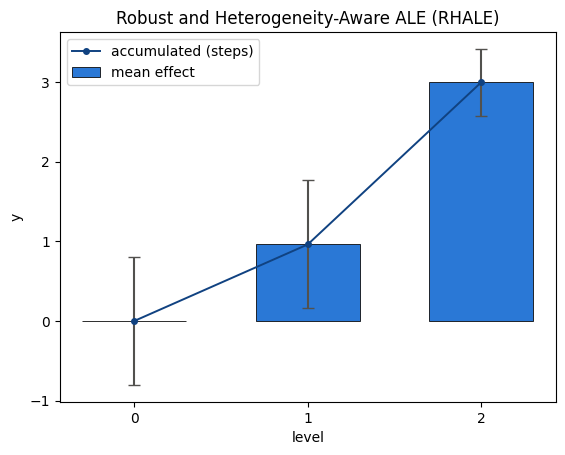

In [7]:
rhale = effector.RHALE(data, model.predict, model.jacobian, schema=schema)
rhale.fit(0, binning_method="greedy", centering="zero_start")
rhale.plot(0, centering="zero_start")

## DerPDP refuses — by design

A derivative needs a continuous axis; the adjacent differences of the PDP bars carry the same information.

In [8]:
derpdp = effector.DerPDP(data, model.predict, model.jacobian, schema=schema)
try:
    derpdp.fit(0)
except ValueError as e:
    print("ValueError:", e)

ValueError: d-pdp does not support ordinal features (feature 0 'level' is ordinal). A derivative needs a continuous axis; use PDP instead — adjacent differences of the per-level PDP bars carry the same information.


## Regional effects on a categorical feature

*For which subgroups is the per-level effect stable?* We use $f(x) = a_{x_0} + b_{x_0}\,\mathbb{1}_{x_2>0}$: the level effect is unstable globally, but perfectly stable once you condition on the $x_2$ gate.

In [9]:
A, B = models.ConditionalCategorical.A, models.ConditionalCategorical.B

def gated_model(x):
    codes = x[:, 0].astype(int)
    return A[codes] + B[codes] * (x[:, 2] > 0)

reg = effector.RegionalPDP(data, gated_model, schema=schema)
reg.fit(0, space_partitioner=effector.space_partitioning.Best(max_depth=1))
reg.summary(0)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 63.01it/s]



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
level 🔹 [id: 0 | heter: 0.20 | inst: 1000 | w: 1.00]
    x2 ≤ 0.00 🔹 [id: 1 | heter: 0.00 | inst: 498 | w: 0.50]
    x2 > 0.00 🔹 [id: 2 | heter: 0.00 | inst: 502 | w: 0.50]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 0.20
    Level 1🔹heter: 0.00 | 🔻0.20 (100.00%)




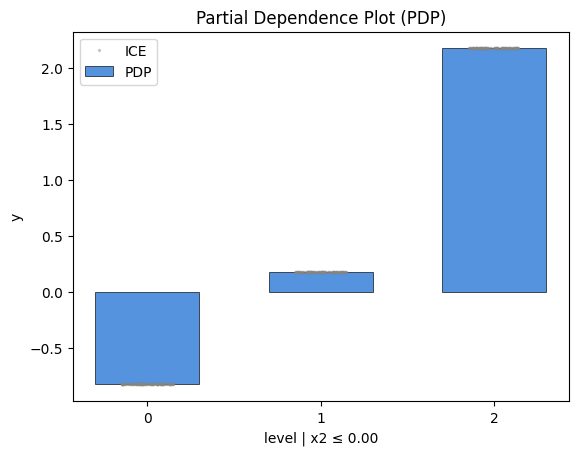

In [10]:
reg.plot(0, node_idx=1, heterogeneity="ice", centering=True)

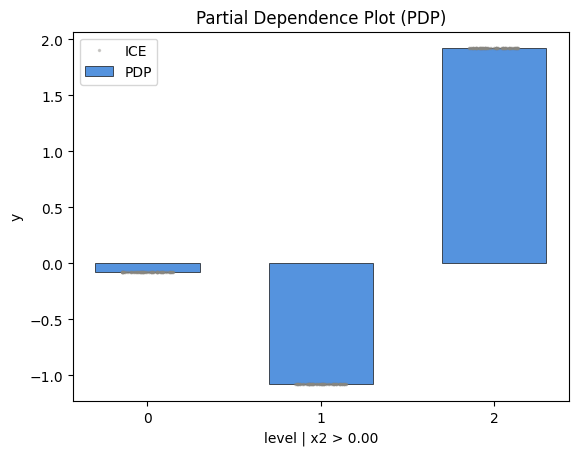

In [11]:
reg.plot(0, node_idx=2, heterogeneity="ice", centering=True)

## Nominal features from a pandas DataFrame

effector is numpy-only, so a DataFrame is converted at the door with `effector.from_dataframe(df)`, which returns `(X, schema)`: `X` is the encoded `(N, D)` numpy matrix and `schema` carries the feature types and the category labels. Your model stays a plain numpy→numpy callable (it receives the encoded codes). Plots translate the codes back to the category labels via the schema.

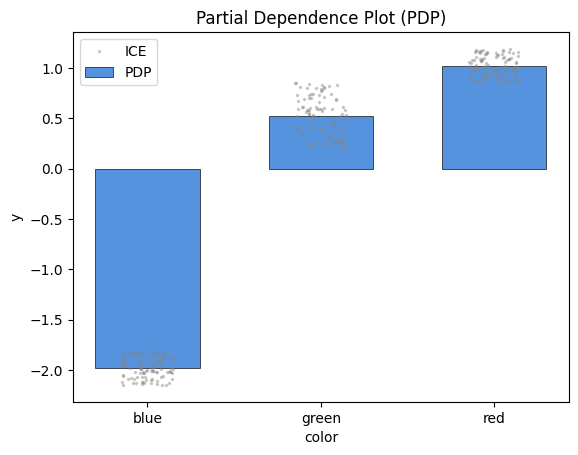

In [12]:
N2 = 800
color = rng.choice(["red", "green", "blue"], N2, p=[0.4, 0.35, 0.25])
df = pd.DataFrame({
    "color": pd.Categorical(color),
    "x1": rng.uniform(-1, 1, N2),
})

# effector is numpy-only: convert the DataFrame to (X, schema) at the door.
X, schema_nominal = effector.from_dataframe(df)
levels = schema_nominal.category_names[0]  # e.g. ['blue', 'green', 'red']

# the model is numpy->numpy; it receives the encoded codes in column 0.
color_effect = {"red": 2.0, "green": 1.5, "blue": -1.0}
effect_by_code = np.array([color_effect[name] for name in levels])
green_code = levels.index("green")

def np_model(x):
    codes = x[:, 0].astype(int)
    return effect_by_code[codes] + 0.5 * x[:, 1] * (codes == green_code)

pdp_nominal = effector.PDP(X, np_model, schema=schema_nominal)
pdp_nominal.plot(0, heterogeneity="ice", centering=True)

### ALE on a nominal feature: the order caveat

ALE accumulates along an order that nominal features do not have. By default effector uses the ascending encoded order and the curve's *shape* depends on it — the meaningful quantities are the adjacent-level differences. You can declare the order (`order=[...]`) or induce it from the other features (`order="similarity"`, Kolmogorov–Smirnov seriation):

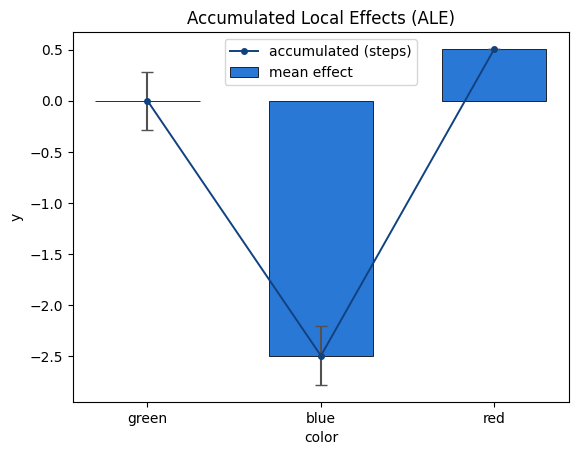

In [13]:
ale_nominal = effector.ALE(X, np_model, schema=schema_nominal)
ale_nominal.fit(0, centering="zero_start", order="similarity")
ale_nominal.plot(0, centering="zero_start")

## Takeaways

- Declare `feature_types` in the `schema` whenever you know them — inference is a fallback, not an oracle.
- PDP/ShapDP treat ordinal and nominal identically (order-free math); ALE needs an order and RHALE additionally needs a *real* one (ordinal only).
- Regional effects answer stability questions per level — heterogeneity is frequency-weighted over the levels.
- The exact formulas per method and feature type live in `docs/method_semantics.md`.